In [1]:
import json
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

Load the JSON and create a master DataFrame of STIX objects

In [2]:
enterprise_file = "../enterprise-attack/enterprise-attack.json"
mobile_file = "../mobile-attack/mobile-attack.json"
ics_file = "../ics-attack/ics-attack.json"

with open(enterprise_file, "r", encoding="utf-8") as f:
    stix = json.load(f)

objects = stix.get("objects", [])
# Master dataframe (keeps the raw dict for reference)
master_df = pd.DataFrame([{
    "id": o.get("id"),
    "type": o.get("type"),
    "name": o.get("name"),
    "description": o.get("description"),
    "created": o.get("created"),
    "modified": o.get("modified"),
    "raw": o
} for o in objects])

master_df.head()


,id,type,name,description,created,modified,raw
0,x-mitre-collection--1f5f1533-f617-4ca8-9ab4-6a...,x-mitre-collection,Enterprise ATT&CK,ATT&CK for Enterprise provides a knowledge bas...,2018-01-17T12:56:55.080Z,2025-11-13T14:00:00.188Z,"{'type': 'x-mitre-collection', 'id': 'x-mitre-..."
1,x-mitre-matrix--eafc1b4c-5e56-4965-bd4e-66a6a8...,x-mitre-matrix,Enterprise ATT&CK,Below are the tactics and technique representi...,2018-10-17T00:14:20.652Z,2025-04-25T14:41:40.982Z,"{'type': 'x-mitre-matrix', 'spec_version': '2...."
2,course-of-action--00d7d21b-69d6-4797-88a2-c86f...,course-of-action,Password Filter DLL Mitigation,Ensure only valid password filters are registe...,2018-10-17T00:14:20.652Z,2025-04-18T17:59:39.912Z,"{'type': 'course-of-action', 'spec_version': '..."
3,course-of-action--02f0f92a-0a51-4c94-9bda-6437...,course-of-action,Space after Filename Mitigation,Prevent files from having a trailing space aft...,2018-10-17T00:14:20.652Z,2025-04-18T17:59:40.127Z,"{'type': 'course-of-action', 'spec_version': '..."
4,course-of-action--03c0c586-50ed-45a7-95f4-f496...,course-of-action,HISTCONTROL Mitigation,Prevent users from changing the <code>HISTCONT...,2018-10-17T00:14:20.652Z,2025-04-18T17:59:40.291Z,"{'type': 'course-of-action', 'spec_version': '..."


Extract techniques (ATT&CK `attack-pattern` objects)

In [3]:
tech_objs = [o for o in objects if o.get("type") == "attack-pattern"]

def technique_row(o):
    # external id e.g. T1003 usually in external_references where source_name == 'mitre-attack'
    ext_refs = o.get("external_references", [])
    mitre_ref = next((r for r in ext_refs if r.get("source_name") == "mitre-attack"), {})
    external_id = mitre_ref.get("external_id")
    # kill_chain_phases may contain tactic phase names
    kcp = o.get("kill_chain_phases") or o.get("kill_chain_phases", []) or []
    phases = [p.get("phase_name") for p in kcp if isinstance(p, dict) and p.get("phase_name")]
    platforms = o.get("x_mitre_platforms") or o.get("x-mitre-platforms") or []
    data_sources = o.get("x_mitre_data_sources") or []
    return {
        "id": o.get("id"),
        "tech_name": o.get("name"),
        "external_id": external_id,
        "description": o.get("description"),
        "platforms": platforms,
        "kill_chain_phases": phases,
        "raw": o
    }

tech_df = pd.DataFrame([technique_row(o) for o in tech_objs])
tech_df.head()


,id,tech_name,external_id,description,platforms,kill_chain_phases,raw
0,attack-pattern--0042a9f5-f053-4769-b3ef-9ad018...,Extra Window Memory Injection,T1055.011,Adversaries may inject malicious code into pro...,[Windows],"[defense-evasion, privilege-escalation]","{'type': 'attack-pattern', 'spec_version': '2...."
1,attack-pattern--005a06c6-14bf-4118-afa0-ebcd8a...,Scheduled Task,T1053.005,Adversaries may abuse the Windows Task Schedul...,[Windows],"[execution, persistence, privilege-escalation]","{'type': 'attack-pattern', 'spec_version': '2...."
2,attack-pattern--005cc321-08ce-4d17-b1ea-cb5275...,Socket Filters,T1205.002,Adversaries may attach filters to a network so...,"[Linux, macOS, Windows]","[defense-evasion, persistence, command-and-con...","{'type': 'attack-pattern', 'spec_version': '2...."
3,attack-pattern--00d0b012-8a03-410e-95de-5826bf...,Indicator Removal from Tools,T1066,If a malicious tool is detected and quarantine...,"[Linux, macOS, Windows]",[defense-evasion],"{'type': 'attack-pattern', 'spec_version': '2...."
4,attack-pattern--00f90846-cbd1-4fc5-9233-df5c2b...,Archive via Utility,T1560.001,Adversaries may use utilities to compress and/...,"[Linux, macOS, Windows]",[collection],"{'type': 'attack-pattern', 'spec_version': '2...."


Extract tactics (from kill_chain_phases) — canonicalize into a DataFrame

In [4]:
# Many ATT&CK bundles don't provide tactic objects as separate 'x-mitre-tactic' entries,
# but techniques include kill_chain_phases referencing 'mitre-attack' phase_name (tactic).
# We'll get the unique list of tactics from the techniques kill_chain_phases:

tactics = sorted({phase for phases in tech_df["kill_chain_phases"].tolist() for phase in phases if phase})
tactics_df = pd.DataFrame({"tactic": tactics})
tactics_df


,tactic
0,collection
1,command-and-control
2,credential-access
3,defense-evasion
4,discovery
5,execution
6,exfiltration
7,impact
8,initial-access
9,lateral-movement


Relationships DataFrame (useful for group->technique and other links)

In [5]:
rel_objs = [o for o in objects if o.get("type") == "relationship"]

rel_df = pd.DataFrame([{
    "id": o.get("id"),
    "relationship_type": o.get("relationship_type"),
    "source_ref": o.get("source_ref"),
    "target_ref": o.get("target_ref"),
    "description": o.get("description"),
    "raw": o
} for o in rel_objs])

rel_df.head()


,id,relationship_type,source_ref,target_ref,description,raw
0,relationship--00038d0e-7fc7-41c3-9055-edb4d87e...,uses,malware--6a21e3a4-5ffe-4581-af9a-6a54c7536f44,attack-pattern--707399d6-ab3e-4963-9315-d9d381...,[Explosive](https://attack.mitre.org/software...,"{'type': 'relationship', 'spec_version': '2.1'..."
1,relationship--0005fb3b-274a-4ac1-8fb2-51366fcd...,mitigates,course-of-action--21da4fd4-27ad-4e9c-b93d-0b9b...,attack-pattern--43c9bc06-715b-42db-972f-52d25c...,Consider blocking download/transfer and execut...,"{'type': 'relationship', 'spec_version': '2.1'..."
2,relationship--000aa4d0-315e-40d7-b2b6-76e91ecf...,uses,intrusion-set--01e28736-2ffc-455b-9880-ed4d140...,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,[Indrik Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'..."
3,relationship--00192a5f-9dc0-445a-b010-d77bd08a...,uses,malware--425771c5-48b4-4ecd-9f95-74ed3fc9da59,attack-pattern--bf176076-b789-408e-8cba-7275e8...,[SombRAT](https://attack.mitre.org/software/S0...,"{'type': 'relationship', 'spec_version': '2.1'..."
4,relationship--001ecf24-8276-40d2-ba05-2d20e5c5...,uses,malware--b7010785-699f-412f-ba49-524da6033c76,attack-pattern--132d5b37-aac5-4378-a8dc-3127b1...,[GoldFinder](https://attack.mitre.org/software...,"{'type': 'relationship', 'spec_version': '2.1'..."


Map techniques to tactics (exploded rows, easy to group)

In [6]:
# explode kill_chain_phases into row-per-technique-per-tactic
tech_exploded = tech_df.explode("kill_chain_phases").rename(columns={"kill_chain_phases":"tactic"})
tech_exploded = tech_exploded[["id","external_id","tech_name","tactic","platforms"]]
tech_exploded.head()

,id,external_id,tech_name,tactic,platforms
0,attack-pattern--0042a9f5-f053-4769-b3ef-9ad018...,T1055.011,Extra Window Memory Injection,defense-evasion,[Windows]
0,attack-pattern--0042a9f5-f053-4769-b3ef-9ad018...,T1055.011,Extra Window Memory Injection,privilege-escalation,[Windows]
1,attack-pattern--005a06c6-14bf-4118-afa0-ebcd8a...,T1053.005,Scheduled Task,execution,[Windows]
1,attack-pattern--005a06c6-14bf-4118-afa0-ebcd8a...,T1053.005,Scheduled Task,persistence,[Windows]
1,attack-pattern--005a06c6-14bf-4118-afa0-ebcd8a...,T1053.005,Scheduled Task,privilege-escalation,[Windows]


## Analyses and Plots

Count techniques per tactic

tactic
defense-evasion         262
persistence             181
privilege-escalation    140
credential-access        80
execution                70
command-and-control      55
discovery                50
resource-development     47
reconnaissance           45
collection               41
impact                   38
lateral-movement         34
initial-access           25
exfiltration             21
Name: id, dtype: int64


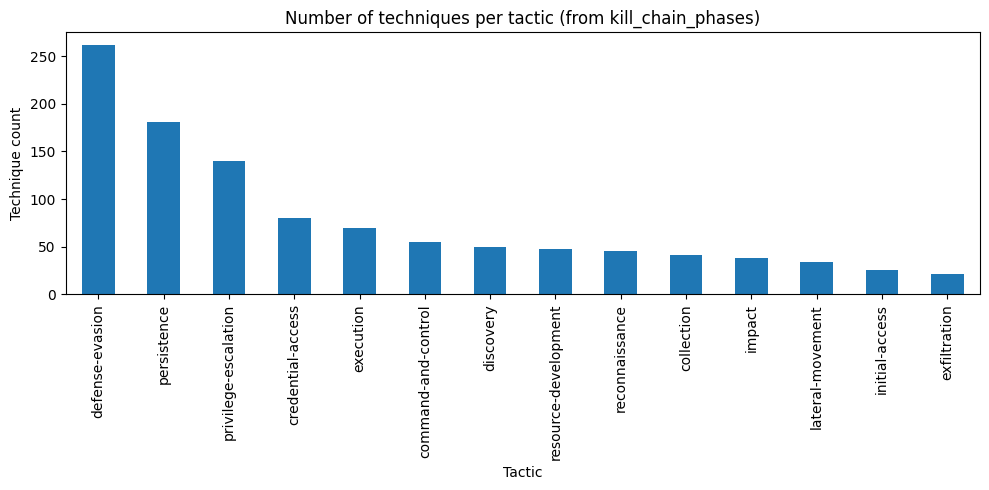

In [7]:
counts = tech_exploded.groupby("tactic")["id"].nunique().sort_values(ascending=False)
print(counts)

# simple bar plot
counts.plot(kind="bar", figsize=(10,5))
plt.title("Number of techniques per tactic (from kill_chain_phases)")
plt.ylabel("Technique count")
plt.xlabel("Tactic")
plt.tight_layout()
plt.show()


Count techniques mentioned by intrusion-sets / groups (via relationships)

In [8]:
# typical ATT&CK IDs: intrusion-set objects have type 'intrusion-set'
# relationships often link intrusion-set -> attack-pattern (technique)
# we can find those refs and join back to technique external_id

# 1) get list of intrusion-set objects and a mapping id->name
intrusion_objs = [o for o in objects if o.get("type") == "intrusion-set"]
intrusion_map = {o["id"]: o.get("name") for o in intrusion_objs}

# 2) filter relationships where target_ref is an attack-pattern id
# Note: target_ref contains full STIX id; match to tech_df.id
rel_is_to_tech = rel_df[rel_df["target_ref"].isin(tech_df["id"])]
# attach intrusion-set name if source_ref is an intrusion-set
rel_is_to_tech["intrusion_set_name"] = rel_is_to_tech["source_ref"].map(intrusion_map)
rel_is_to_tech = rel_is_to_tech.dropna(subset=["intrusion_set_name"])
rel_is_to_tech = rel_is_to_tech.merge(tech_df[["id","external_id","tech_name"]], left_on="target_ref", right_on="id", how="left")
rel_is_to_tech.head()

# Count by intrusion-set
counts_by_is = rel_is_to_tech.groupby("intrusion_set_name")["external_id"].nunique().sort_values(ascending=False)
print(counts_by_is.head(20))


intrusion_set_name
Kimsuky              109
Lazarus Group         93
APT28                 91
Mustang Panda         85
APT41                 82
Volt Typhoon          81
Magic Hound           79
Sandworm Team         79
APT32                 78
OilRig                76
Gamaredon Group       70
Turla                 68
FIN7                  67
APT29                 66
Scattered Spider      64
Wizard Spider         64
Chimera               59
MuddyWater            58
Threat Group-3390     57
Medusa Group          57
Name: external_id, dtype: int64


/tmp/ipykernel_26432/2689066225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rel_is_to_tech["intrusion_set_name"] = rel_is_to_tech["source_ref"].map(intrusion_map)


Build a bipartite graph (intrusion-set <-> technique)


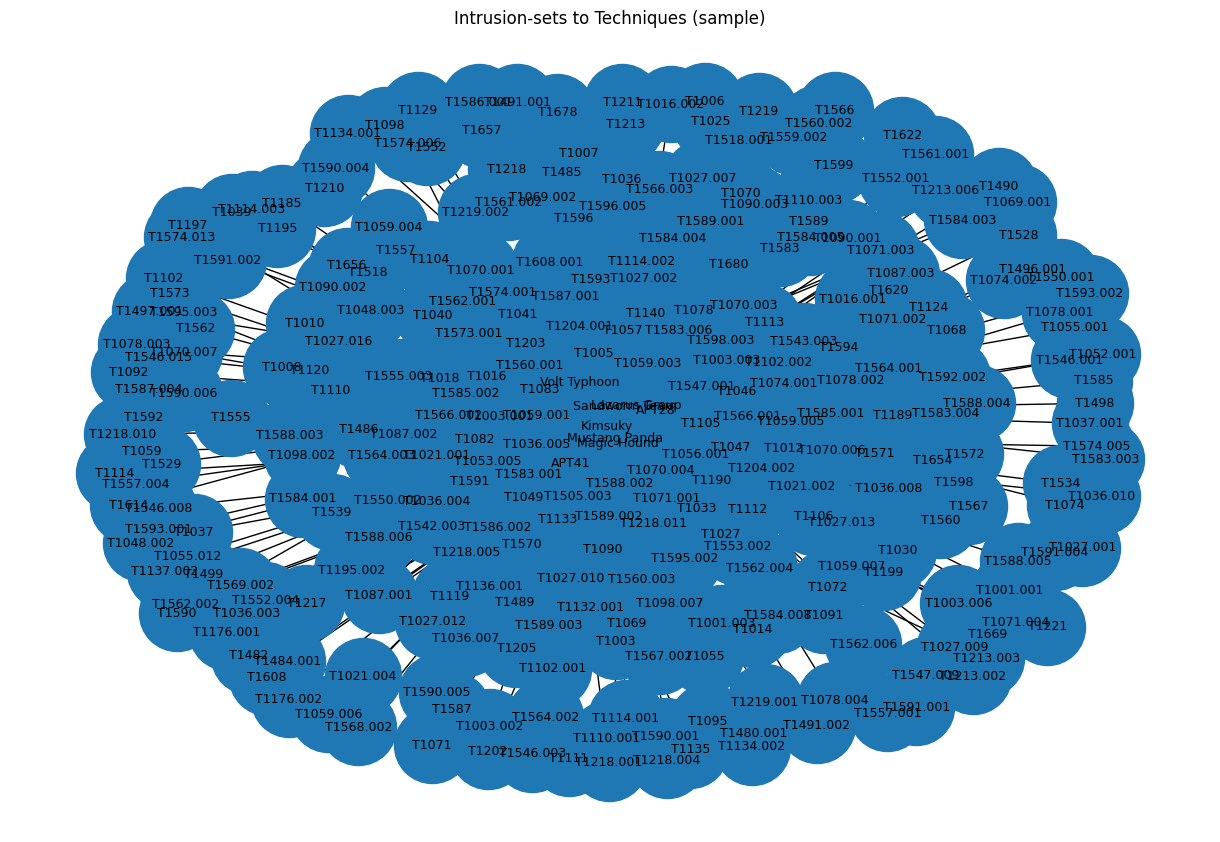

In [9]:
# Build NetworkX bipartite graph
G = nx.Graph()
# add intrusion-set nodes
for is_id, is_name in intrusion_map.items():
    G.add_node(is_name, bipartite="intrusion-set")
# add technique nodes and edges
for _, row in rel_is_to_tech.iterrows():
    is_name = row["intrusion_set_name"]
    tech = f"{row['external_id'] or row['tech_name']}"
    G.add_node(tech, bipartite="technique")
    G.add_edge(is_name, tech)

# Draw a small subgraph (limit to top 10 intrusion-sets by degree to keep it readable)
top_is = counts_by_is.head(8).index.tolist()
sub_nodes = set(top_is)
for n in top_is:
    sub_nodes |= set(G.neighbors(n))
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(subG, k=0.5)
nx.draw(subG, pos, with_labels=True, node_size=3000, font_size=9)
plt.title("Intrusion-sets to Techniques (sample)")
plt.show()


In [10]:
# Filter relationships where source is intrusion-set and target is attack-pattern (technique)
rel_uses = rel_df[
    (rel_df["relationship_type"] == "uses") &
    (rel_df["source_ref"].str.startswith("intrusion-set")) &
    (rel_df["target_ref"].str.startswith("attack-pattern"))
].copy()

# Map intrusion-set names
rel_uses["intrusion_set_name"] = rel_uses["source_ref"].map(intrusion_map)

# Join in technique info (external_id and name)
rel_uses = rel_uses.merge(
    tech_df[["id", "external_id", "tech_name"]],
    left_on="target_ref", right_on="id", how="left"
)

rel_uses.head()


,id_x,relationship_type,source_ref,target_ref,description,raw,intrusion_set_name,id_y,external_id,tech_name
0,relationship--000aa4d0-315e-40d7-b2b6-76e91ecf...,uses,intrusion-set--01e28736-2ffc-455b-9880-ed4d140...,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,[Indrik Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'...",Indrik Spider,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,T1003.001,LSASS Memory
1,relationship--002f1039-f4c5-4c60-b8ac-ced374be...,uses,intrusion-set--b7f627e2-0817-4cd5-8d50-e75f8aa...,attack-pattern--10ffac09-e42d-4f56-ab20-db94c6...,[LuminousMoth](https://attack.mitre.org/groups...,"{'type': 'relationship', 'spec_version': '2.1'...",LuminousMoth,attack-pattern--10ffac09-e42d-4f56-ab20-db94c6...,T1539,Steal Web Session Cookie
2,relationship--003071c1-a640-4f29-8405-a3998dfa...,uses,intrusion-set--918da025-04bd-48af-b6c4-f3e4d1b...,attack-pattern--f5d8eed6-48a9-4cdf-a3d7-d1ffa9...,[Medusa Group](https://attack.mitre.org/groups...,"{'type': 'relationship', 'spec_version': '2.1'...",Medusa Group,attack-pattern--f5d8eed6-48a9-4cdf-a3d7-d1ffa9...,T1490,Inhibit System Recovery
3,relationship--0038b0b8-f51c-4fd1-8b04-2fd7ebd1...,uses,intrusion-set--dd2d9ca6-505b-4860-a604-233685b...,attack-pattern--635cbe30-392d-4e27-978e-667743...,[Wizard Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'...",Wizard Spider,attack-pattern--635cbe30-392d-4e27-978e-667743...,T1136.001,Local Account
4,relationship--00561c3c-345e-4578-95c3-b7e0a95d...,uses,intrusion-set--3753cc21-2dae-4dfb-8481-d004e74...,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,[FIN7](https://attack.mitre.org/groups/G0046) ...,"{'type': 'relationship', 'spec_version': '2.1'...",FIN7,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,T1204.001,Malicious Link


In [11]:
# Count total number of unique intrusion sets using each technique
tech_use_counts = (
    rel_uses.groupby(["external_id", "tech_name"])["intrusion_set_name"]
    .nunique()  # number of distinct intrusion sets per technique
    .reset_index(name="use_count")
    .sort_values("use_count", ascending=False)
)

tech_use_counts.head(10)


,external_id,tech_name,use_count
153,T1105,Ingress Tool Transfer,85
208,T1204.002,Malicious File,84
88,T1059.001,PowerShell,83
414,T1588.002,Tool,79
360,T1566.001,Spearphishing Attachment,77
89,T1059.003,Windows Command Shell,71
54,T1036.005,Match Legitimate Resource Name or Location,59
112,T1071.001,Web Protocols,56
288,T1547.001,Registry Run Keys / Startup Folder,55
126,T1082,System Information Discovery,55


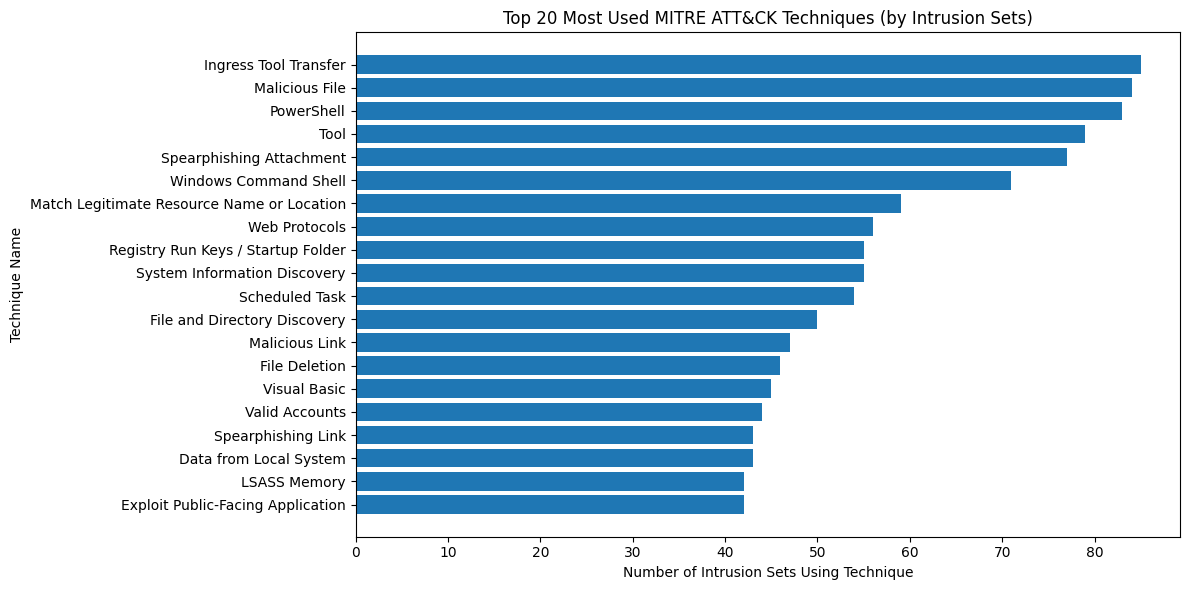

In [12]:
# Sort by use_count descending and keep top 20 techniques
top_techs = tech_use_counts.sort_values("use_count", ascending=False).head(20)

plt.figure(figsize=(12, 6))
plt.barh(
    top_techs["tech_name"][::-1],   # ← show names on Y-axis
    top_techs["use_count"][::-1],   # ← counts on X-axis
)

plt.title("Top 20 Most Used MITRE ATT&CK Techniques (by Intrusion Sets)")
plt.xlabel("Number of Intrusion Sets Using Technique")
plt.ylabel("Technique Name")
plt.tight_layout()
plt.show()


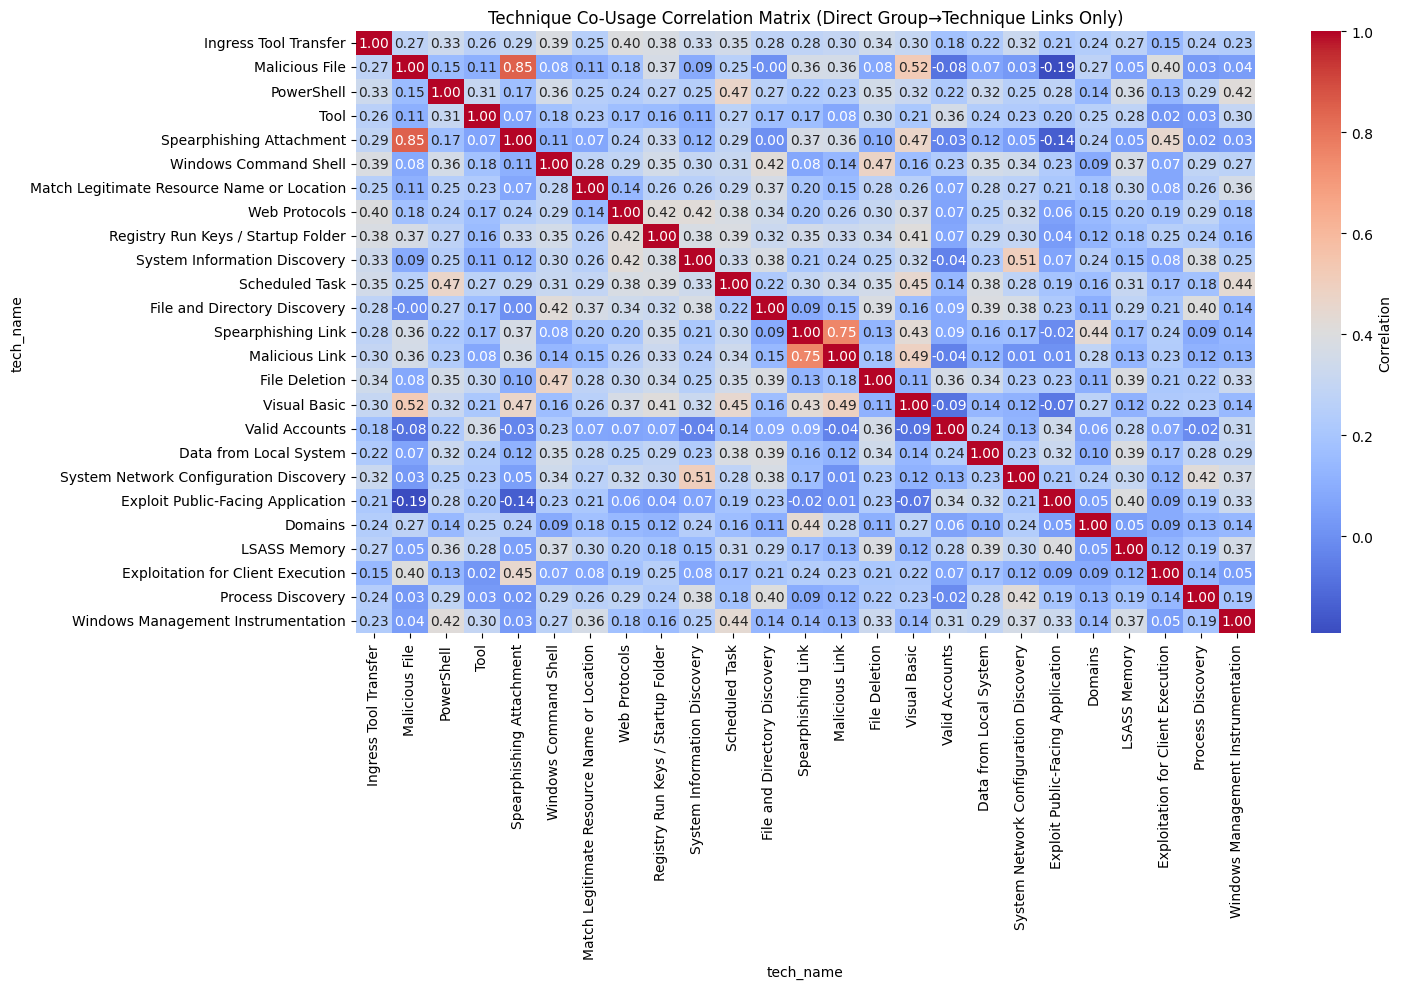

In [13]:
# Use ONLY direct group→technique relationships (already created earlier as rel_uses)
direct_df = rel_uses[["intrusion_set_name", "external_id", "tech_name"]].dropna()

# 1️⃣ Pivot into a binary matrix:
# Rows = intrusion sets, Columns = techniques, Values = 1 if group uses technique
usage_matrix_direct = (
    direct_df
    .assign(value=1)
    .pivot_table(
        index="intrusion_set_name",
        columns="tech_name",
        values="value",
        fill_value=0
    )
)

# 2️⃣ Compute correlation between techniques
corr_matrix_direct = usage_matrix_direct.corr()

# 3️⃣ (Optional) Focus on the top N most-used techniques to keep visualization readable
top_techs_direct = (
    direct_df.groupby("tech_name")["intrusion_set_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .index
)

corr_subset_direct = corr_matrix_direct.loc[top_techs_direct, top_techs_direct]

# 4️⃣ Visualize as a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_subset_direct,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"},
)
plt.title("Technique Co-Usage Correlation Matrix (Direct Group→Technique Links Only)")
plt.tight_layout()
plt.show()
